In [1]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon, Point, box, MultiPoint
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.interpolate import griddata
from matplotlib.ticker import StrMethodFormatter, MaxNLocator

In [2]:
from utils.site import Site
from utils.tree import Tree
from utils.constants import GH_TREE_COORDS_FILEPATH, SILVER_FOLDERPATH

In [3]:
df = pd.read_excel(GH_TREE_COORDS_FILEPATH)
df.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850


In [4]:
# 155 sites, spread across 6 regions
print("# sites:", df["Site Name"].nunique())
print("# regions:", df["Région"].nunique())
print("# site per regions:")
df.groupby('Région')['Site Name'].nunique().sort_values()

# sites: 155
# regions: 6
# site per regions:


Région
Brong-Ahafo      15
Eastern          18
Central          20
Western-South    31
Ashanti          32
Western-North    39
Name: Site Name, dtype: int64

In [5]:
# No site spread across two regions
df.groupby('Site Name')['Région'].nunique().unique()

array([1])

In [6]:
# Each site has 5 trees
print("# trees per site:")
df.groupby('Site Name')['Tree N.'].count().unique()

# trees per site:


array([5])

In [7]:
# Add points 
df['point'] = df.apply(axis=1, func=lambda row: Point((row["Tree Longitude"], row["Tree Latitude"])))
df.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude,point
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049,POINT (-1.173049 5.323065)
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774,POINT (-1.157774 5.431284)
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850,POINT (-1.18585 5.538543)


In [8]:
gdf = gpd.GeoDataFrame(df, geometry="point", crs="EPSG:4326")
gdf.head(3)

,Pays,Région,Region code,Site Nb,Site Name,Tree N.,Tree Latitude,Tree Longitude,point
0,Ghana,Central,CR,1,FO05,T1,5.323065,-1.173049,POINT (-1.17305 5.32306)
1,Ghana,Central,CR,2,FO06,T1,5.431284,-1.157774,POINT (-1.15777 5.43128)
2,Ghana,Central,CR,3,FO07,T1,5.538543,-1.185850,POINT (-1.18585 5.53854)


In [9]:
sites = []
for site_name, row_idxs in df.groupby('Site Name').groups.items():
    trees = []
    for _, row in df.iloc[row_idxs].iterrows():
        lon_lat = (row["Tree Longitude"], row["Tree Latitude"])
        t = Tree(point=Point(lon_lat))
        trees.append(t)

    s = Site(trees=trees, name=site_name, region=row['Région'])
    sites.append(s)

In [12]:
# All convex-hulls areas
print("# m2 of confirmed-cocoa trees:", sum(e.area_m2 for e in sites))

# m2 of confirmed-cocoa trees: 179775.05632365667


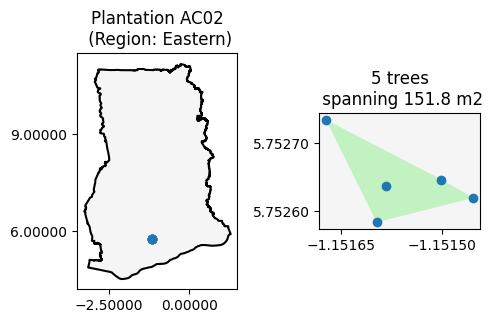

In [13]:
sites[1].plot()

In [14]:
import joblib
joblib.dump(sites, SILVER_FOLDERPATH / "sites.pkl")

['/home/aga/Documents/clients/forestero/skymap/skymap/data/silver/sites.pkl']